In [15]:
import ast
def read_dat(path):
    """Parse a .dat file whose lines look like:
       (p, l, k_min, k_max, [d0, d1, ...])
    Returns a list of (p, l, k_min, k_max, data) tuples."""
    entries = []
    with open(path) as f:
        for lineno, line in enumerate(f, 1):
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            try:
                p, l, k_min, k_max, data = ast.literal_eval(line)
            except (ValueError, SyntaxError) as e:
                raise ValueError(f"{path}:{lineno}: malformed line: {line!r}") from e
            entries.append((int(p), int(l), int(k_min), int(k_max), [float(x) for x in data]))
    return entries

#l=3

maximal_l_eq_2_filename = "l-2_maximal_bound-error.dat"
submaximal_index_p_l_eq_2_filename = "l-2_submaximal_index_p_bound-error.dat"
submaximal_index_q_l_eq_2_filename = "l-2_submaximal_index_q_q-eq-5_bound-error.dat"
submaximal_index_q2_l_eq_2_filename = "l-2_submaximal_index_q2_q-eq-5_bound-error.dat"
submaximal_index_p2_l_eq_2_filename = "l-2_submaximal_index_p2_bound-error.dat"

maximal_l_eq_2_array = read_dat(maximal_l_eq_2_filename);
submaximal_index_p_l_eq_2_array = read_dat(submaximal_index_p_l_eq_2_filename)
submaximal_index_q_l_eq_2_array = read_dat(submaximal_index_q_l_eq_2_filename)
submaximal_index_q2_l_eq_2_array = read_dat(submaximal_index_q2_l_eq_2_filename)
submaximal_index_p2_l_eq_2_array = read_dat(submaximal_index_p2_l_eq_2_filename)

#l=3

maximal_l_eq_3_filename = "l-3_maximal_bound-error.dat"
submaximal_index_p_l_eq_3_filename = "l-3_submaximal_index_p_bound-error.dat"
submaximal_index_q_l_eq_3_filename = "l-3_submaximal_index_q_q-eq-5_bound-error.dat"
submaximal_index_q2_l_eq_3_filename = "l-3_submaximal_index_q2_q-eq-5_bound-error.dat"
submaximal_index_p2_l_eq_3_filename = "l-3_submaximal_index_p2_bound-error.dat"

maximal_l_eq_3_array = read_dat(maximal_l_eq_3_filename);
submaximal_index_p_l_eq_3_array = read_dat(submaximal_index_p_l_eq_3_filename)
submaximal_index_q_l_eq_3_array = read_dat(submaximal_index_q_l_eq_3_filename)
submaximal_index_q2_l_eq_3_array = read_dat(submaximal_index_q2_l_eq_3_filename)
submaximal_index_p2_l_eq_3_array = read_dat(submaximal_index_p2_l_eq_3_filename)

In [16]:
import ast
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize, LinearSegmentedColormap
from mpl_toolkits.mplot3d.art3d import Line3DCollection

# SVG is vector-based, so dpi does not affect its line/text sharpness.
# Keep text as text for easier editing in Illustrator/Inkscape.
mpl.rcParams.update({
    "figure.dpi": 150,              # interactive display only
    "savefig.dpi": 600,             # raster fallback only
    "savefig.format": "svg",
    "svg.fonttype": "none",        # preserve text as editable SVG text
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

BLUE_RED = LinearSegmentedColormap.from_list(
    "blue_red", ["#0d2be0", "#d40000"]
)


def read_dat(path):
    """Parse lines of the form:
    (p, l, k_min, k_max, [d0, d1, ...])
    """
    entries = []
    with open(path, encoding="utf-8") as f:
        for lineno, line in enumerate(f, 1):
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            try:
                p, l, k_min, k_max, data = ast.literal_eval(line)
            except (ValueError, SyntaxError) as e:
                raise ValueError(
                    f"{path}:{lineno}: malformed line: {line!r}"
                ) from e
            entries.append((
                int(p), int(l), int(k_min), int(k_max),
                [float(x) for x in data],
            ))
    return entries


def plot_entries(
    entries, title=None, connect=False, ax=None, save=None,
    stems=False, stem_base=None, cmap=BLUE_RED,
    vmin=None, vmax=None, colorbar=True, s=2,
    elev_value=30, azim_value=-30, figsize=(10, 8),
):
    """Create a 3D plot with k on x, p on y, and data on z.

    Set save="figure.svg" for a publication-quality vector export.
    Optionally save a PNG fallback with save="figure.png" and dpi=600.
    """
    if ax is None:
        fig = plt.figure(figsize=figsize, constrained_layout=True)
        ax = fig.add_subplot(projection="3d")
    else:
        fig = ax.get_figure()

    cmap = plt.get_cmap(cmap) if isinstance(cmap, str) else cmap
    ax.view_init(elev=elev_value, azim=azim_value)

    all_z = np.concatenate([
        np.asarray(entry[4], dtype=float) for entry in entries
    ])
    lo = all_z.min() if vmin is None else vmin
    hi = all_z.max() if vmax is None else vmax
    if lo == hi:
        lo, hi = lo - 0.5, hi + 0.5
    norm = Normalize(vmin=lo, vmax=hi)

    if stem_base is None:
        stem_base = float(all_z.min())

    for p, l, k_min, k_max, data in entries:
        zs = np.asarray(data, dtype=float)
        ks = np.arange(k_min, k_min + len(zs))
        ys = np.full(len(ks), float(p))
        colors = cmap(norm(zs))

        if stems:
            segments = [
                ((k, y, stem_base), (k, y, z))
                for k, y, z in zip(ks, ys, zs)
            ]
            ax.add_collection3d(Line3DCollection(
                segments, colors=colors, linewidths=0.6, alpha=0.5
            ))

        if connect and len(zs) > 1:
            points = np.column_stack([ks, ys, zs])
            segments = np.stack([points[:-1], points[1:]], axis=1)
            mid_colors = cmap(norm(0.5 * (zs[:-1] + zs[1:])))
            ax.add_collection3d(Line3DCollection(
                segments, colors=mid_colors, linewidths=1.0, alpha=0.85
            ))

        ax.scatter(
            ks, ys, zs, c=colors, s=s,
            depthshade=False, edgecolors="none", rasterized=False,
        )

    # Collections do not participate reliably in autoscaling.
    zlo = min(all_z.min(), stem_base)
    zhi = max(all_z.max(), stem_base)
    pad = 0.05 * (zhi - zlo) or 1.0
    ax.set_zlim(zlo - pad, zhi + pad)

    ax.set_xlabel("k", labelpad=8)
    ax.set_ylabel("p", labelpad=8)
    ax.set_zlabel("value", labelpad=8)
    if title:
        ax.set_title(title, pad=12)

    if colorbar:
        sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.10, label="value")

    if save is not None:
        save = Path(save)
        if save.suffix.lower() != ".svg":
            save = save.with_suffix(".svg")
        fig.savefig(
            save,
            format="svg",
            bbox_inches="tight",
            metadata={"Creator": "Matplotlib"},
        )

    return fig, ax


# Example usage:
# entries = read_dat("l-2_maximal_bound-error.dat")
# fig, ax = plot_entries(
#     entries,
#     title="l = 2",
#     connect=True,
#     stems=False,
#     save="l2_maximal_bound_error.svg",
# )
# plt.show()


(<Figure size 1500x1200 with 2 Axes>,
 <Axes3DSubplot: title={'center': 'maximal, l=2, p_max ~ 50000'}, xlabel='k', ylabel='p', zlabel='value'>)

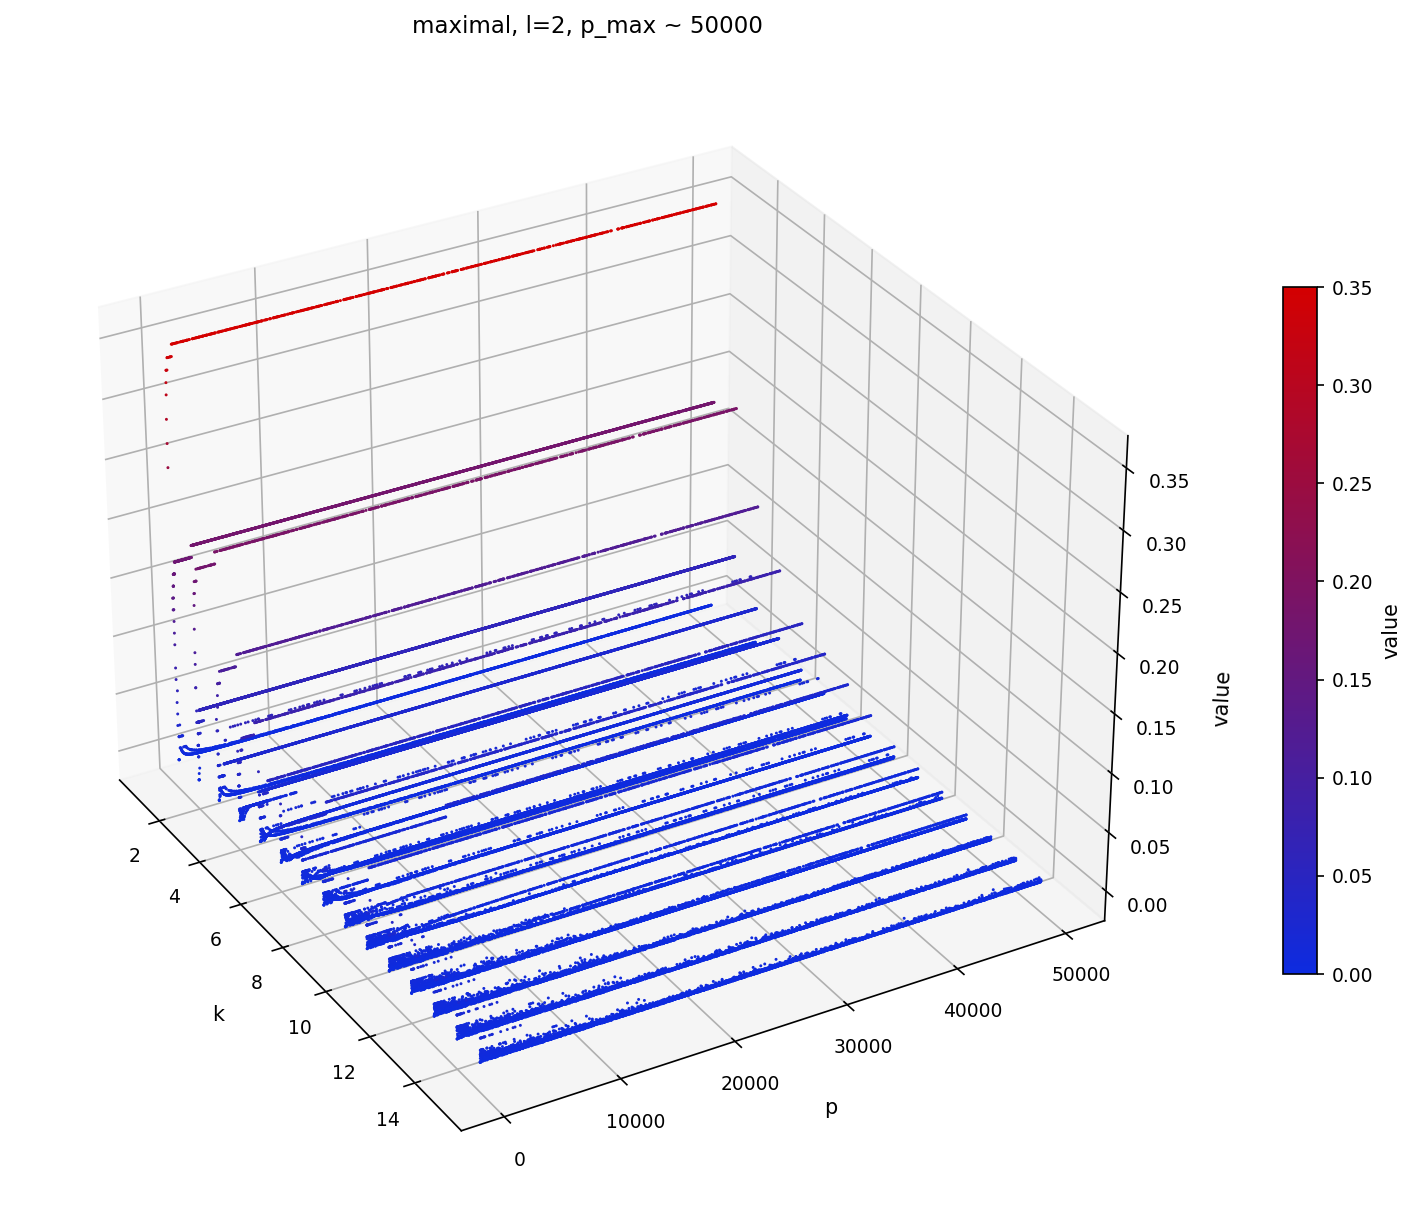

In [17]:
plot_entries(maximal_l_eq_2_array, title="maximal, l=2, p_max ~ 50000", save = "maximal_l-2.svg")

(<Figure size 1500x1200 with 2 Axes>,
 <Axes3DSubplot: title={'center': 'maximal, l=3, p_max ~ 50000'}, xlabel='k', ylabel='p', zlabel='value'>)

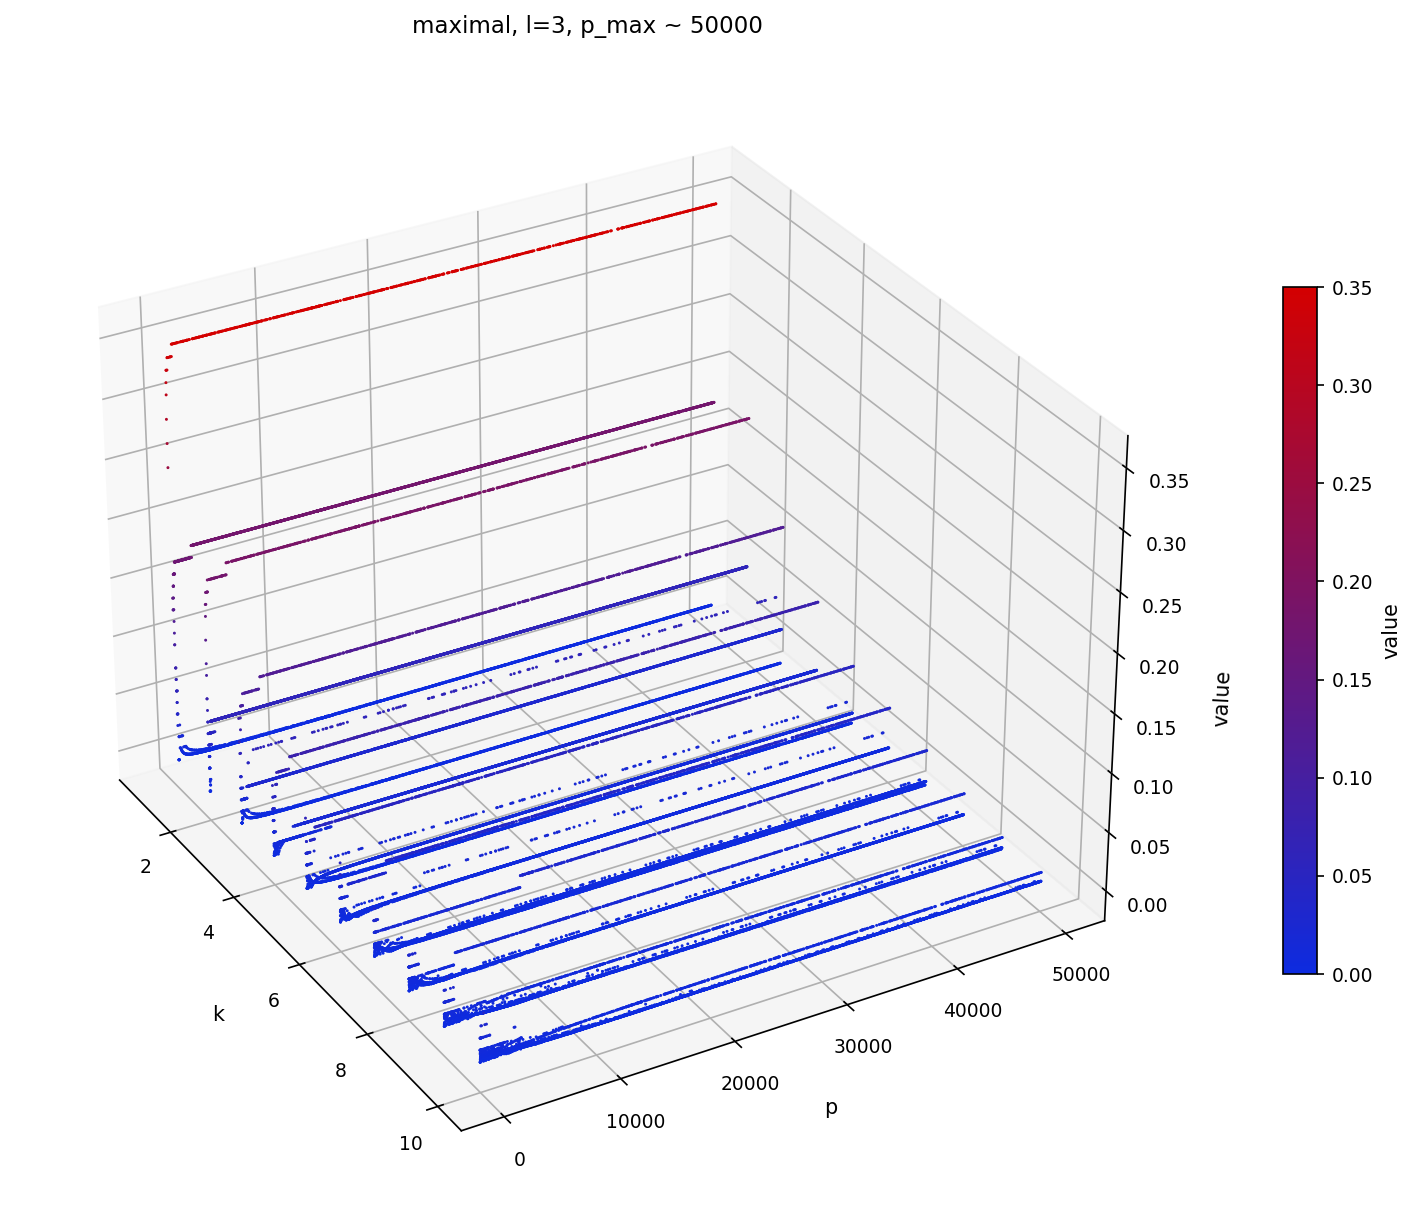

In [18]:
plot_entries(maximal_l_eq_3_array, title="maximal, l=3, p_max ~ 50000", save = "maximal_l-3.svg")

(<Figure size 1500x1200 with 2 Axes>,
 <Axes3DSubplot: title={'center': 'submaximal index p, l=2, p_max ~ 50000'}, xlabel='k', ylabel='p', zlabel='value'>)

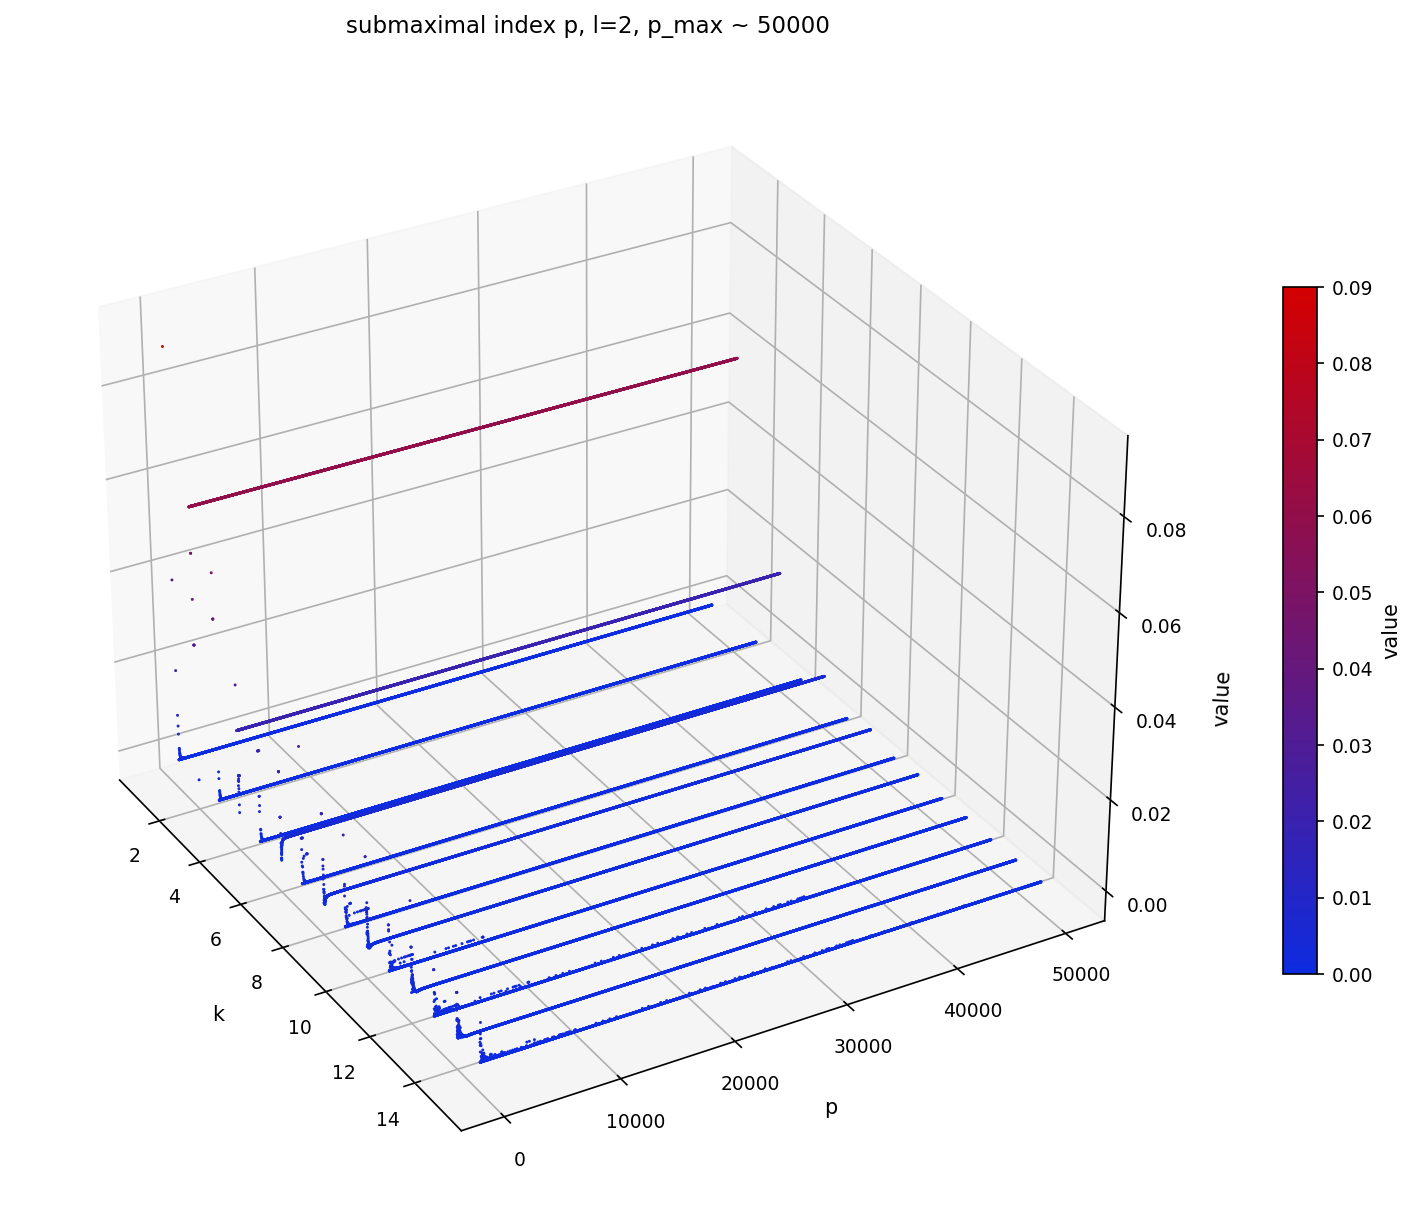

In [19]:
plot_entries(submaximal_index_p_l_eq_2_array, title="submaximal index p, l=2, p_max ~ 50000", save = "submaximal_index_p-l_2.svg")

(<Figure size 1500x1200 with 2 Axes>,
 <Axes3DSubplot: title={'center': 'submaximal index p, l=3, p_max ~ 50000'}, xlabel='k', ylabel='p', zlabel='value'>)

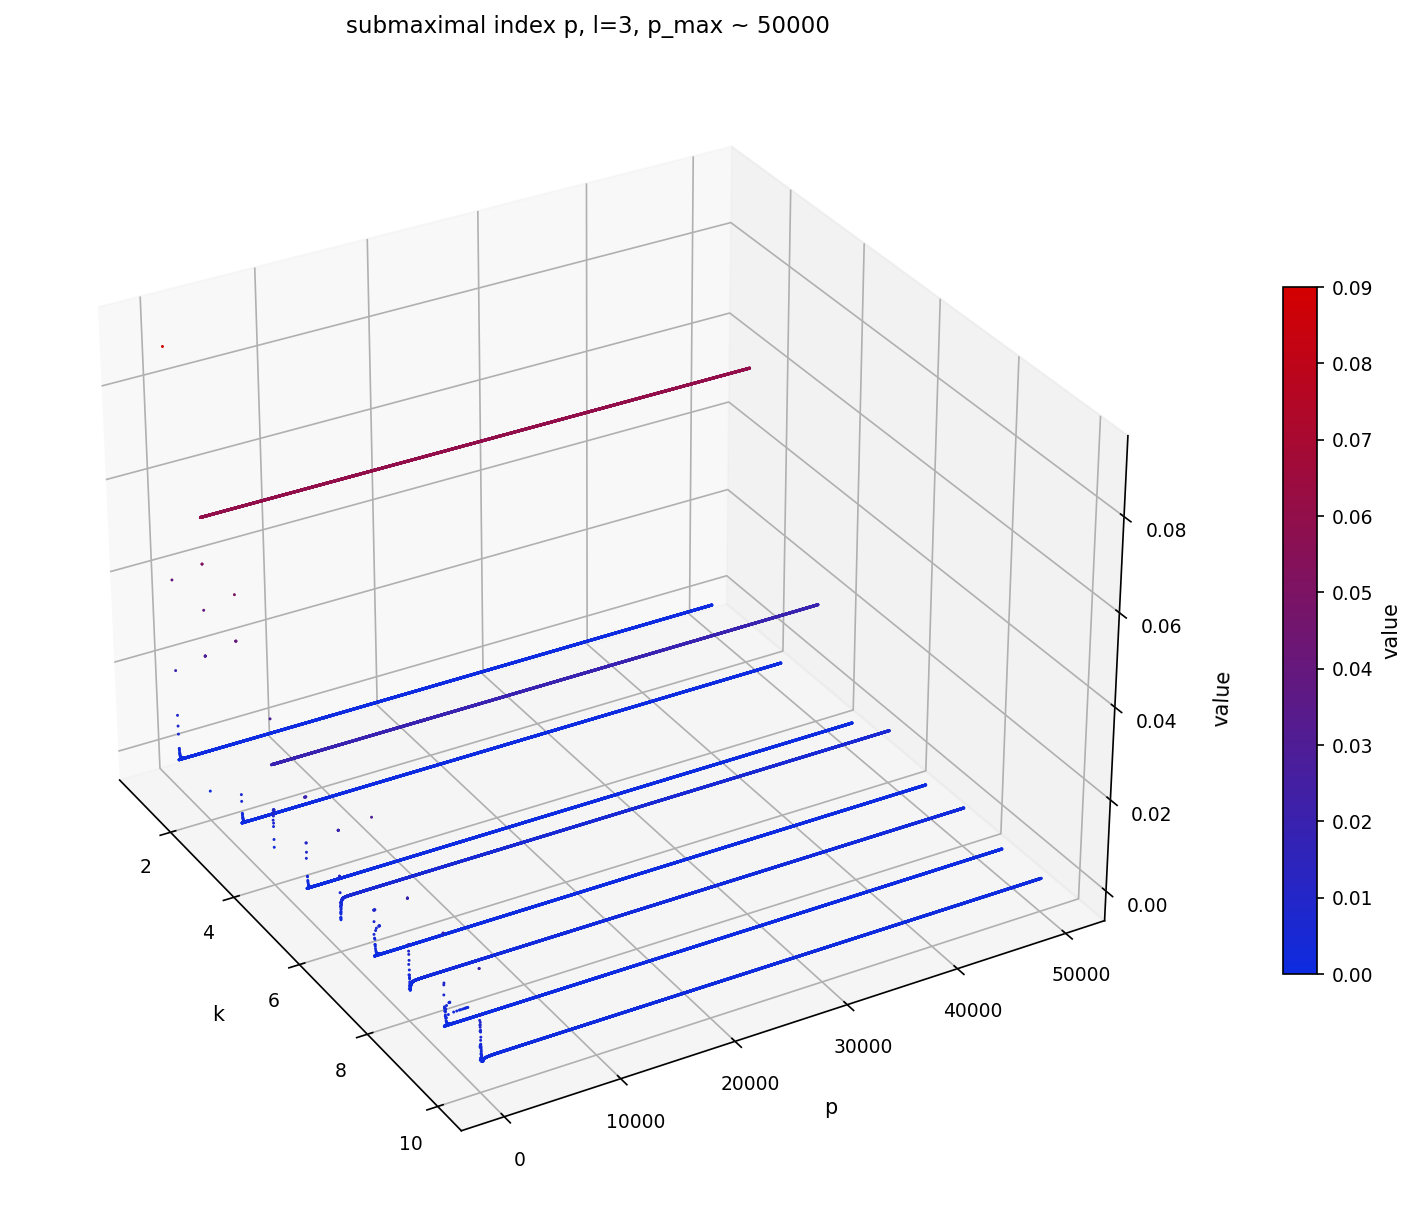

In [20]:
plot_entries(submaximal_index_p_l_eq_3_array, title="submaximal index p, l=3, p_max ~ 50000", save = "submaximal_index_p-l_3.svg")

(<Figure size 1500x1200 with 2 Axes>,
 <Axes3DSubplot: title={'center': 'submaximal index r=5, l=2, p_max ~ 50000'}, xlabel='k', ylabel='p', zlabel='value'>)

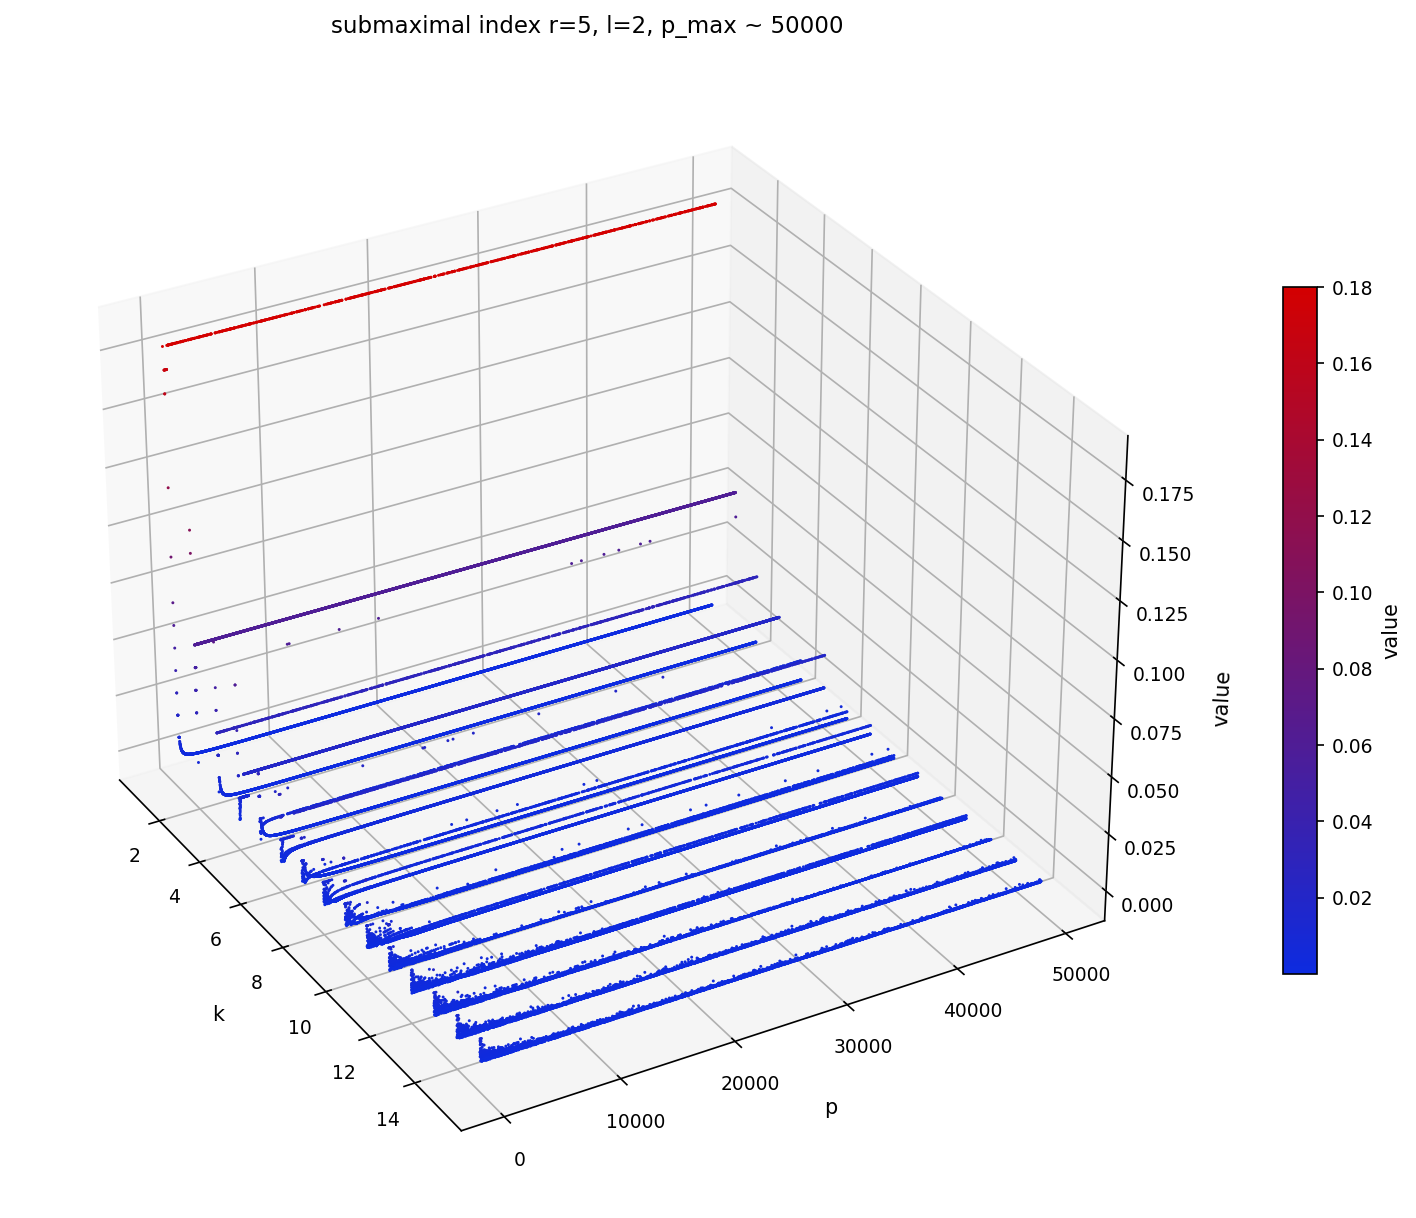

In [21]:
plot_entries(submaximal_index_q_l_eq_2_array, title="submaximal index r=5, l=2, p_max ~ 50000", save = "submaximal_index_q-l_2.svg")

(<Figure size 1500x1200 with 2 Axes>,
 <Axes3DSubplot: title={'center': 'submaximal index q=r, l=3, p_max ~ 50000'}, xlabel='k', ylabel='p', zlabel='value'>)

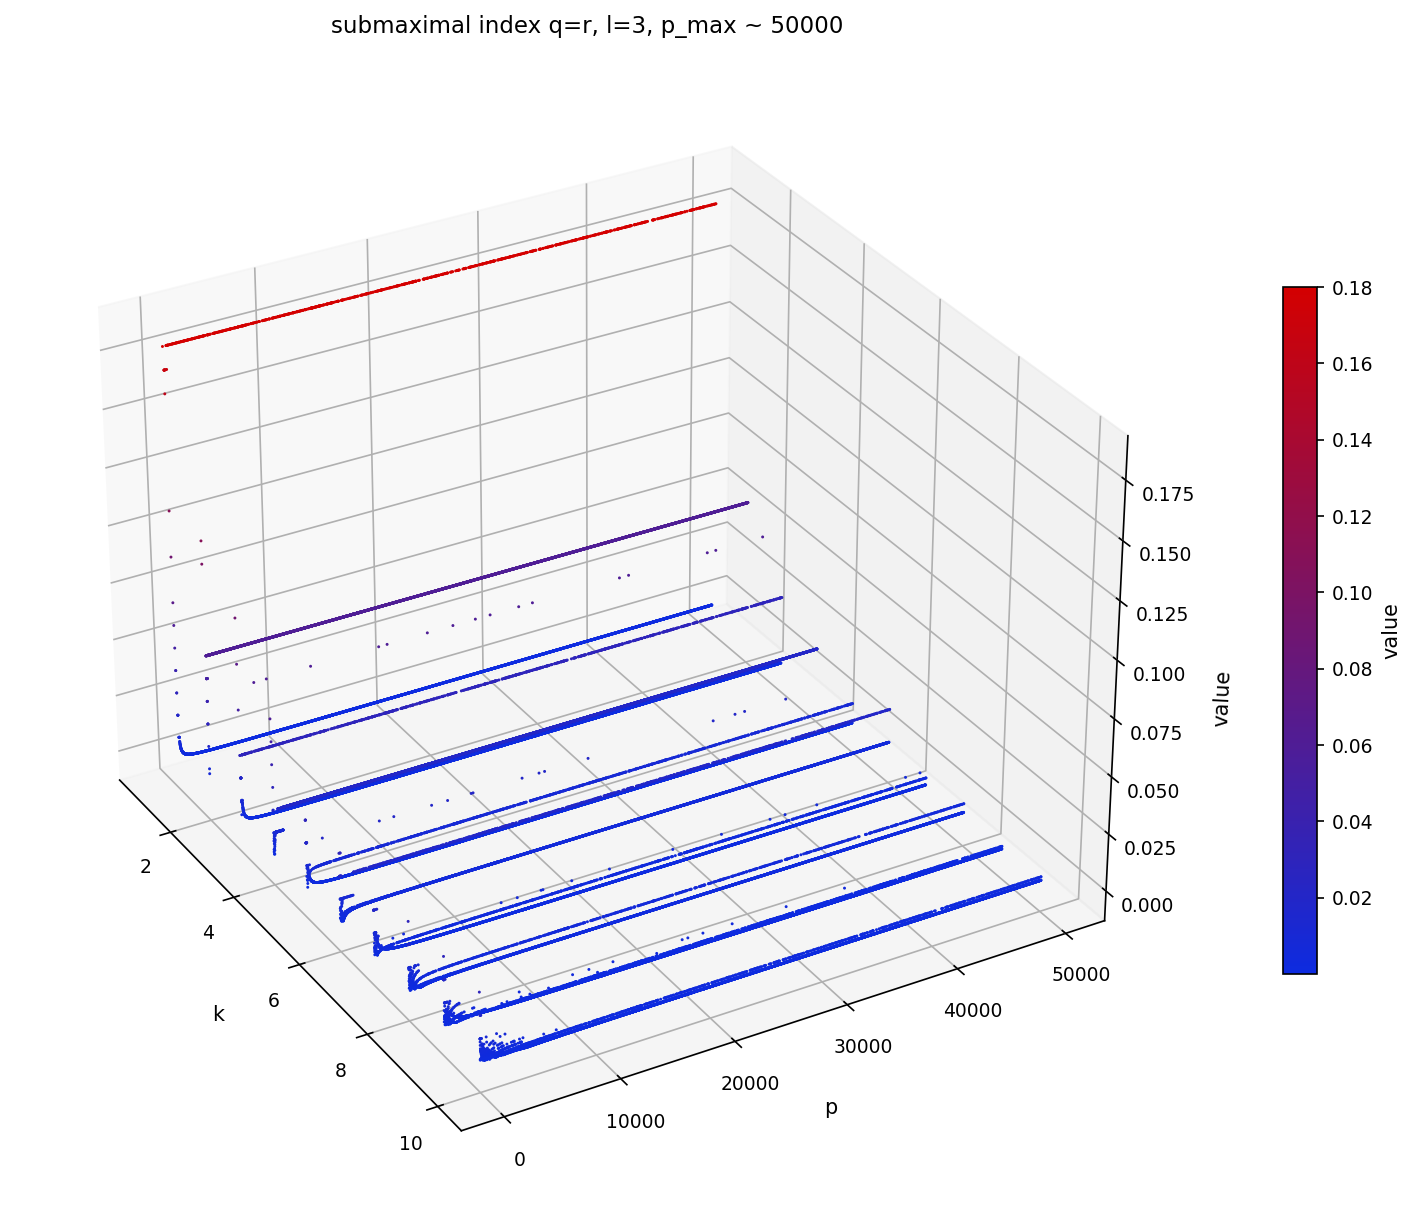

In [22]:
plot_entries(submaximal_index_q_l_eq_3_array, title="submaximal index q=r, l=3, p_max ~ 50000", save = "submaximal_index_q-l_3.svg")

(<Figure size 1500x1200 with 2 Axes>,
 <Axes3DSubplot: title={'center': 'submaximal index r^2=25, l=2, p_max ~ 50000'}, xlabel='k', ylabel='p', zlabel='value'>)

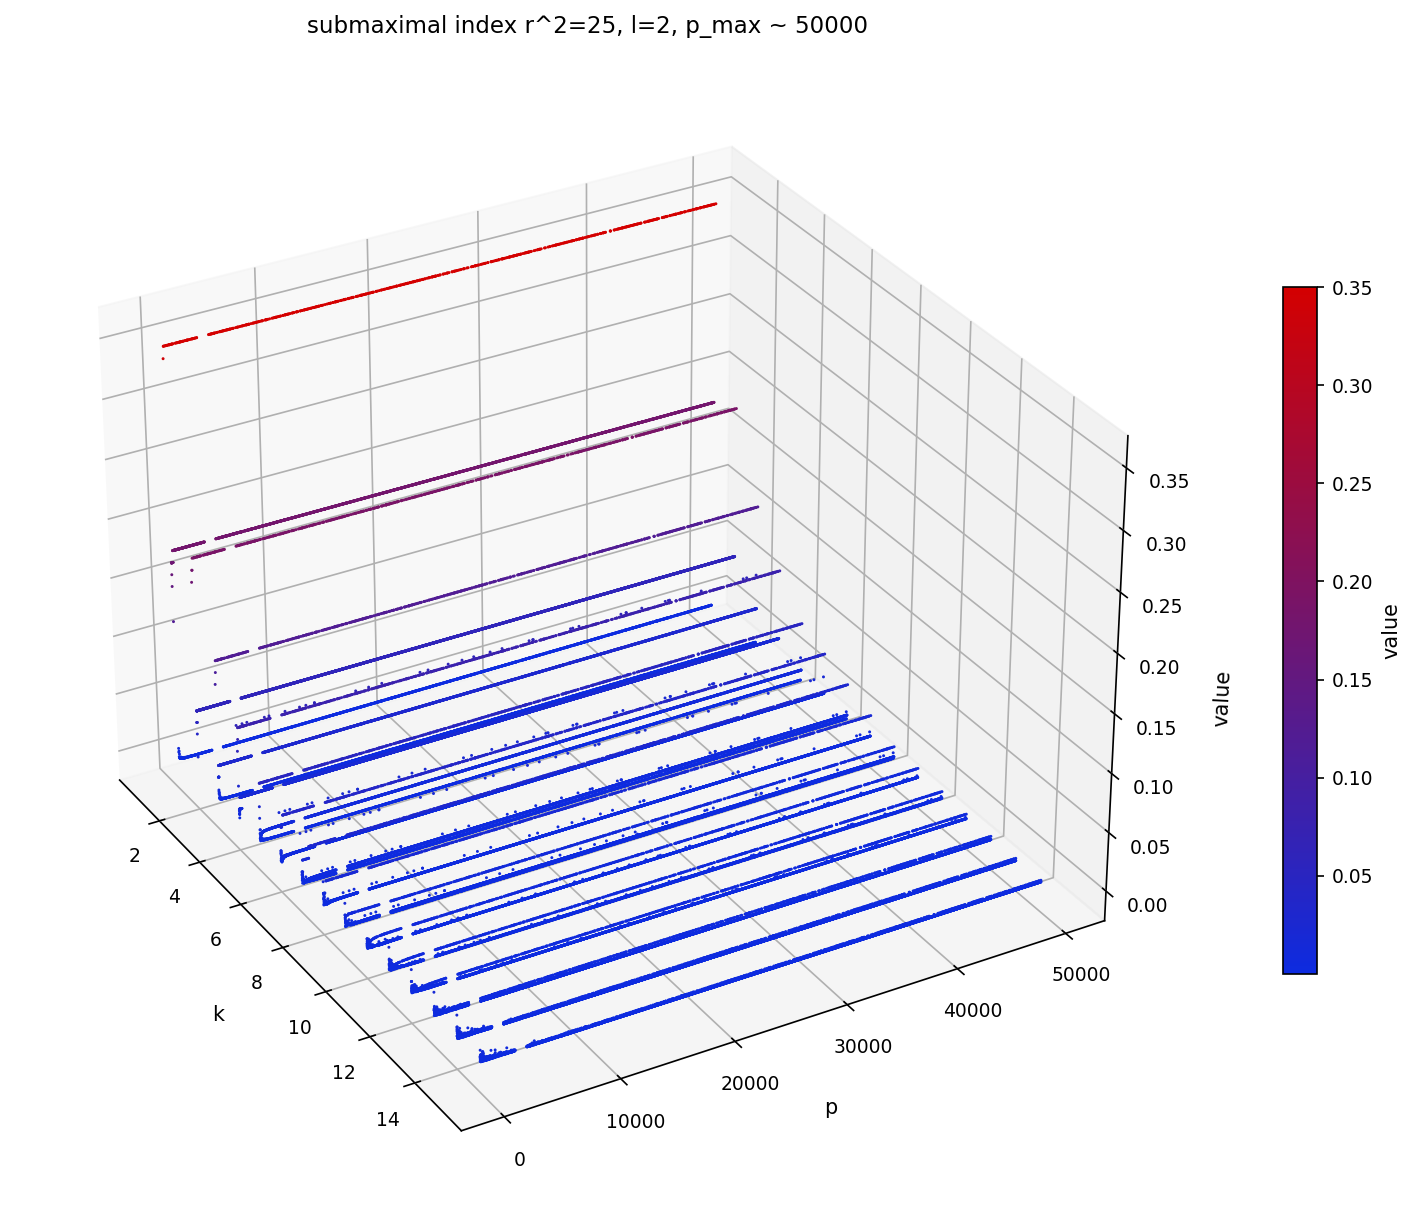

In [23]:
plot_entries(submaximal_index_q2_l_eq_2_array, title="submaximal index r^2=25, l=2, p_max ~ 50000", save = "submaximal_index_q2-l_2.svg")

(<Figure size 1500x1200 with 2 Axes>,
 <Axes3DSubplot: title={'center': 'submaximal index r^2=25, l=3, p_max ~ 50000'}, xlabel='k', ylabel='p', zlabel='value'>)

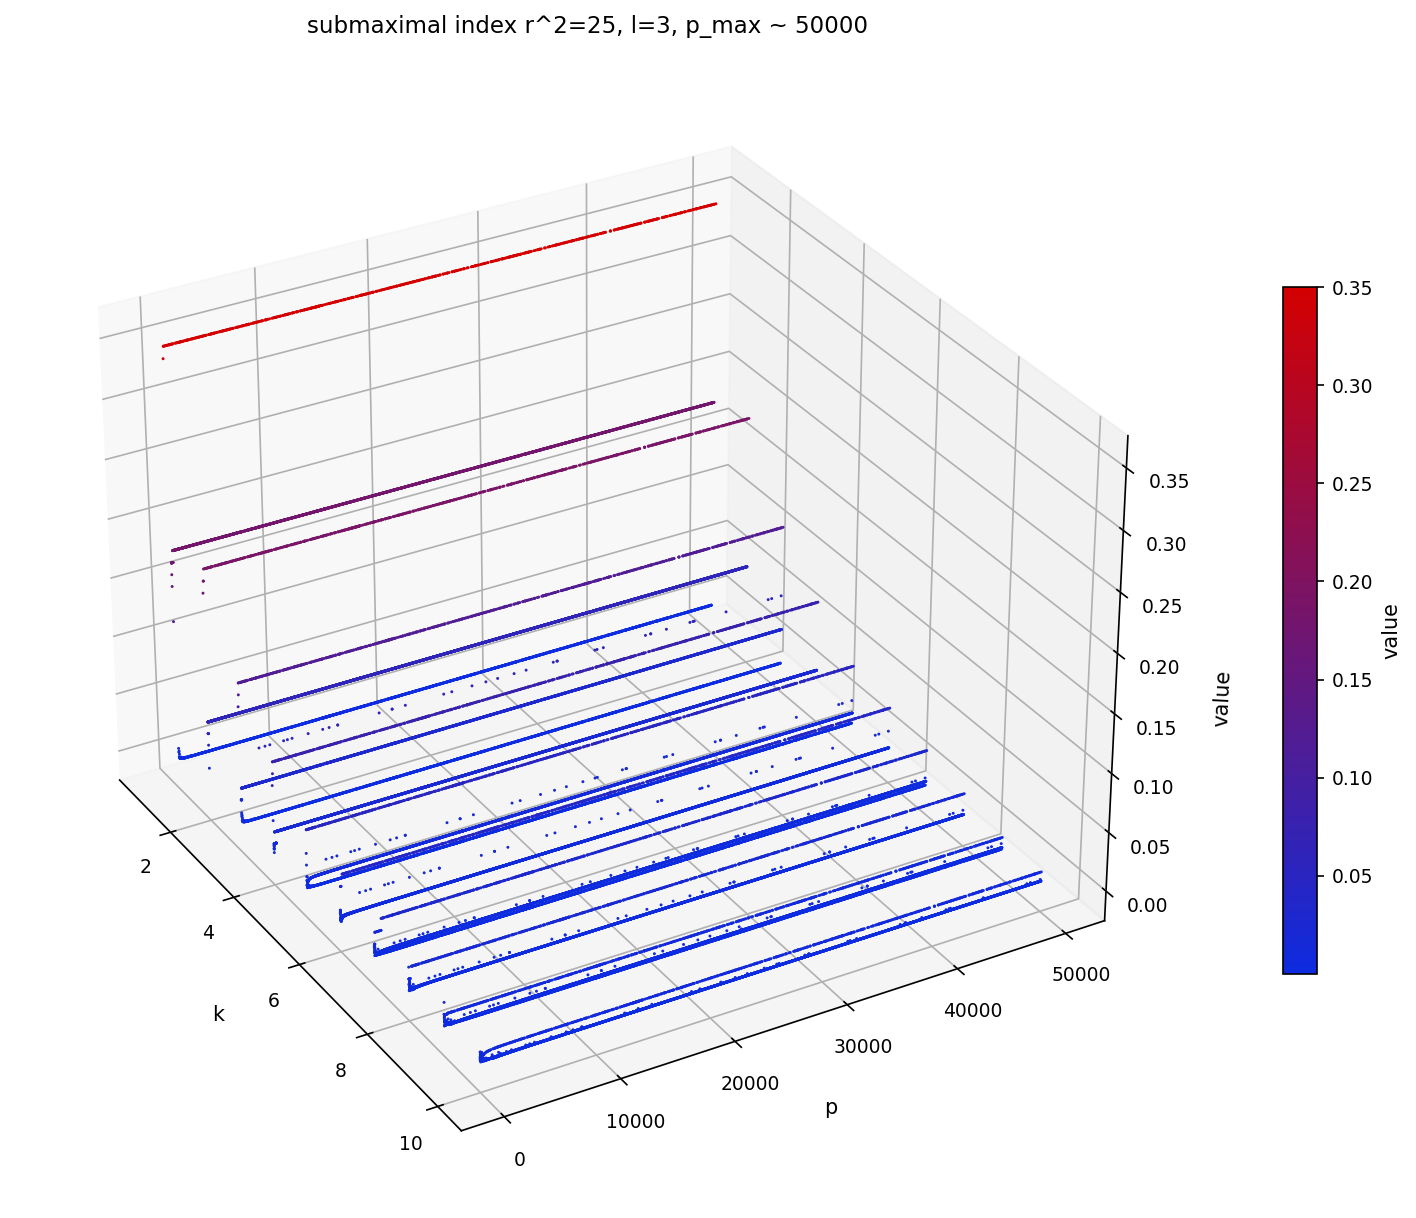

In [24]:
plot_entries(submaximal_index_q2_l_eq_3_array, title="submaximal index r^2=25, l=3, p_max ~ 50000", save = "submaximal_index_q2-l_3.svg")

(<Figure size 1500x1200 with 2 Axes>,
 <Axes3DSubplot: title={'center': 'submaximal index p^2, l=2, p_max ~ 50000'}, xlabel='k', ylabel='p', zlabel='value'>)

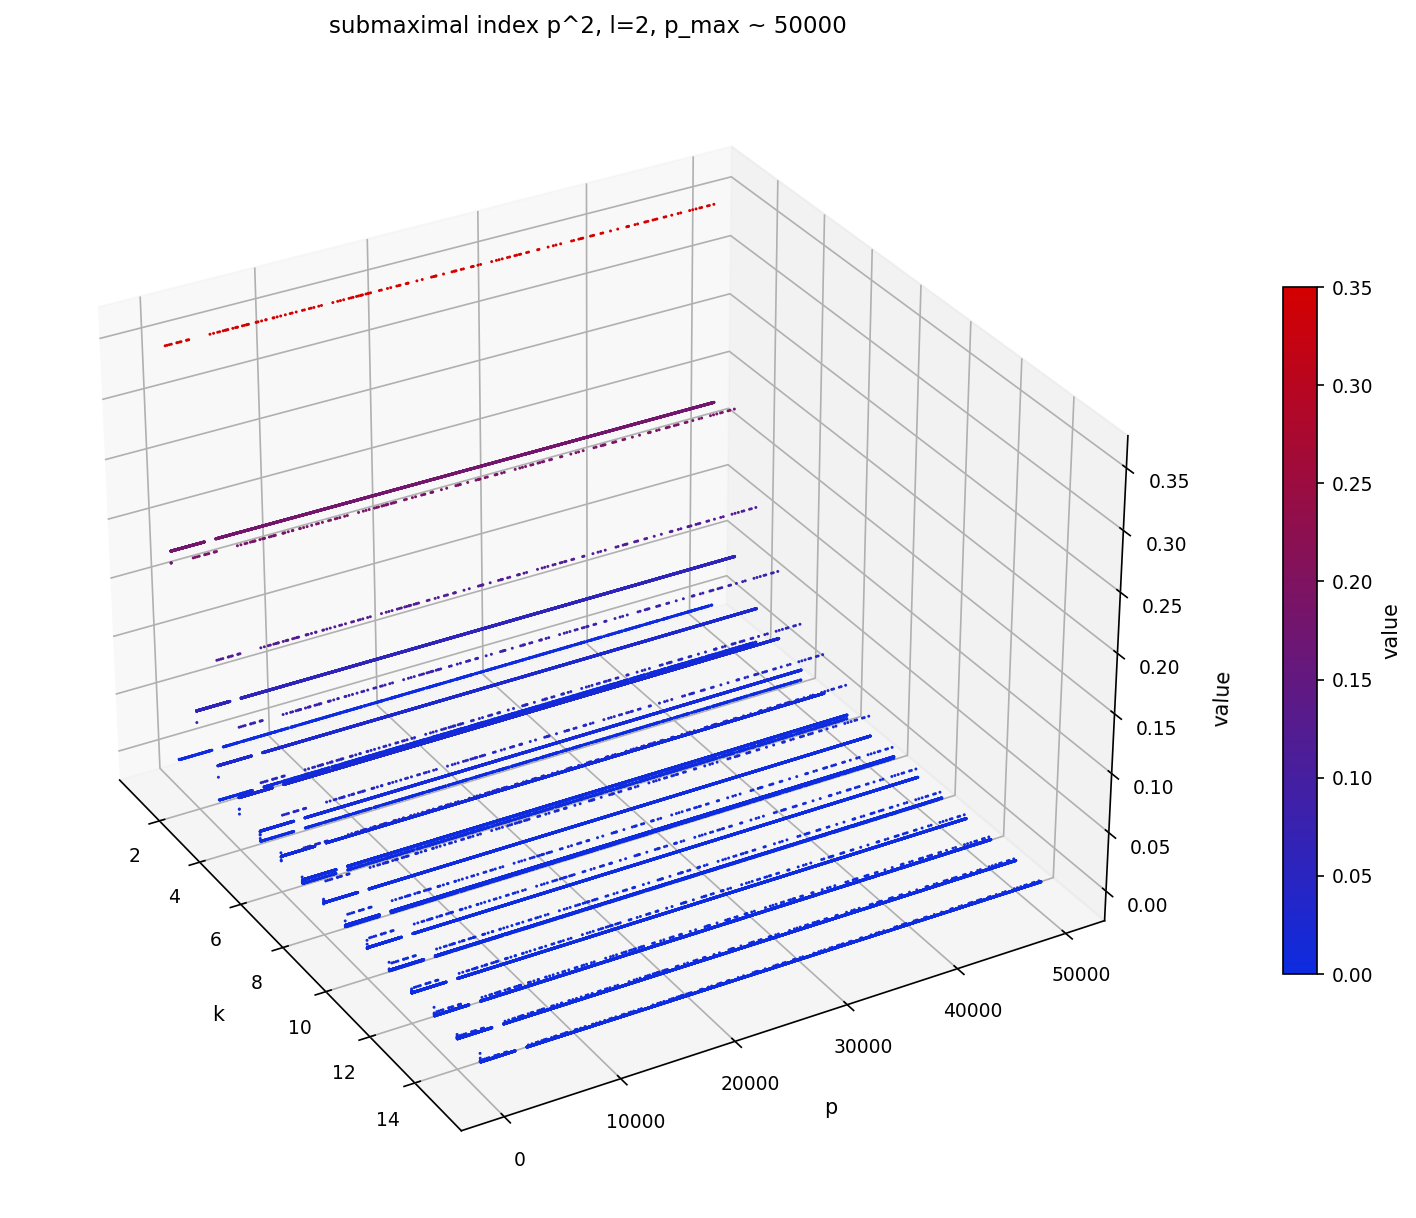

In [25]:
plot_entries(submaximal_index_p2_l_eq_2_array, title="submaximal index p^2, l=2, p_max ~ 50000", save = "submaximal_index_p2-l_2.svg")

(<Figure size 1500x1200 with 2 Axes>,
 <Axes3DSubplot: title={'center': 'submaximal index p^2, l=3, p_max ~ 50000'}, xlabel='k', ylabel='p', zlabel='value'>)

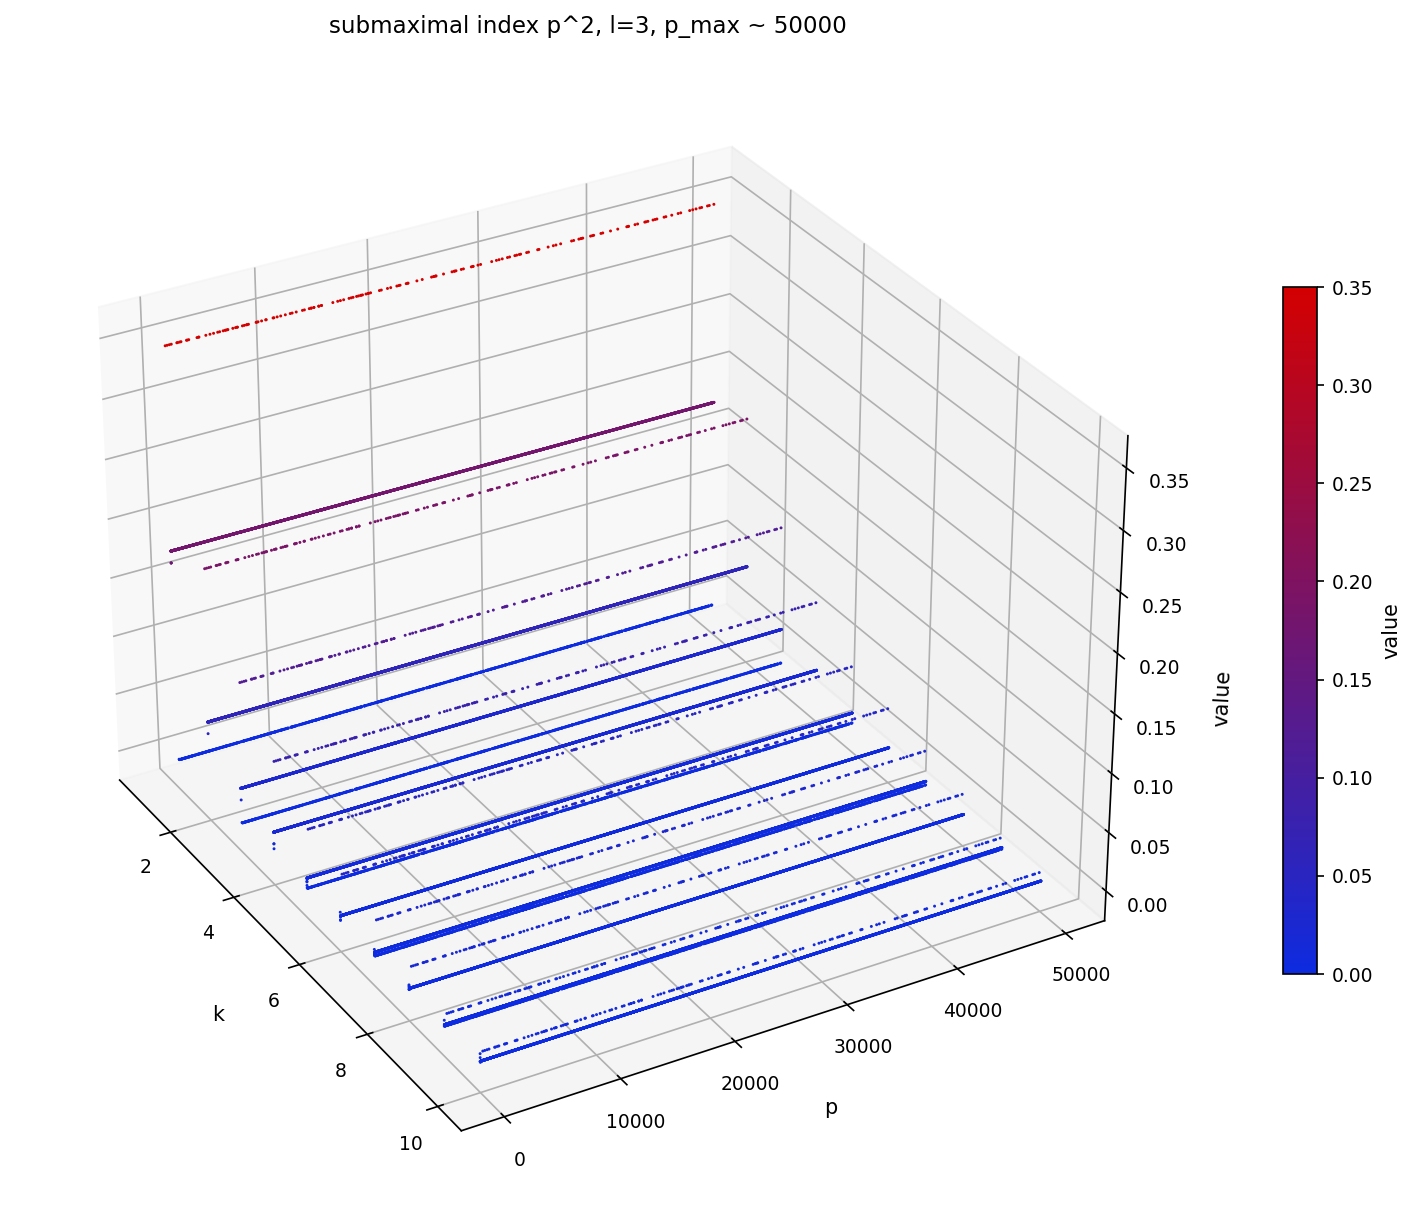

In [26]:
plot_entries(submaximal_index_p2_l_eq_3_array, title="submaximal index p^2, l=3, p_max ~ 50000", save = "submaximal_index_p2-l_3.svg")